In [1]:
pip install tensorflow==2.12.0 mediapipe==0.10.9 opencv-python numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\asiddiqui\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [3]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [5]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [6]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [ ]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [8]:
draw_landmarks(frame, results)

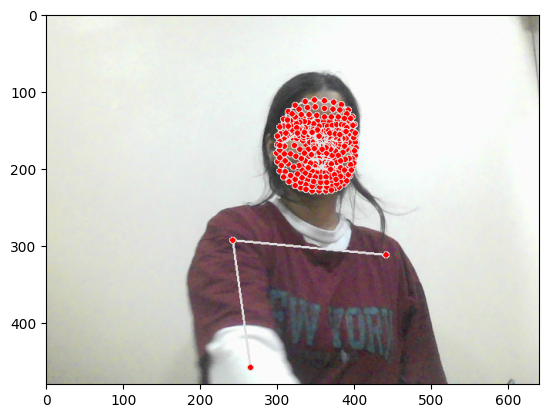

In [9]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [10]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [11]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [12]:
if results.face_landmarks:
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten()
else:
    face = np.zeros(1404)

In [13]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [14]:
result_test = extract_keypoints(results)

In [15]:
result_test

array([ 0.56080329,  0.3649126 , -0.61671591, ...,  0.        ,
        0.        ,  0.        ])

In [16]:
np.save('0', result_test)

In [17]:
np.load('0.npy')

array([ 0.56080329,  0.3649126 , -0.61671591, ...,  0.        ,
        0.        ,  0.        ])

In [18]:
os.path

<module 'ntpath' from 'c:\\Users\\asiddiqui\\AppData\\Local\\Programs\\Python\\Python310\\lib\\ntpath.py'>

In [ ]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('ISL_MP_Data') 

# Actions that we try to detect
actions = np.array(['Nice to meet you',
                    'I am learning sign',
                    'Whats your name',
                    'Where are you from',
                    'How are you',
                    'I am fine',
                    'What time is it',
                    'Where do you work',
                    'Thank you',
                    'Excuse me'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

In [27]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [34]:
actions = np.array(['Where do you work'])

In [36]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
#                 print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [37]:
cap.release()
cv2.destroyAllWindows()

In [38]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [40]:
label_map = {label:num for num, label in enumerate(actions)}
label_map

{'Nice to meet you': 0,
 'I am learning sign': 1,
 'Whats your name': 2,
 'Where are you from': 3,
 'How are you': 4,
 'I am fine': 5,
 'What time is it': 6,
 'Where do you work': 7,
 'Thank you': 8,
 'Excuse me': 9}

In [41]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [42]:
np.array(sequences).shape

(300, 30, 1662)

In [43]:
np.array(labels).shape

(300,)

In [44]:
X = np.array(sequences)

In [45]:
X.shape

(300, 30, 1662)

In [46]:
y = to_categorical(labels).astype(int)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [48]:
y_test.shape

(15, 10)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard


In [50]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [53]:
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
lstm_model.add(LSTM(128, return_sequences=True, activation='relu'))
lstm_model.add(LSTM(64, return_sequences=False, activation='relu'))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(actions.shape[0], activation='softmax'))

lstm_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
lstm_history = lstm_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])


Epoch 1/260
9/9 [==============================] - 5s 157ms/step - loss: 4.6585 - categorical_accuracy: 0.1123 - val_loss: 2.6434 - val_categorical_accuracy: 0.0667
Epoch 2/260
9/9 [==============================] - 1s 96ms/step - loss: 2.4121 - categorical_accuracy: 0.0596 - val_loss: 2.2139 - val_categorical_accuracy: 0.1333
Epoch 3/260
9/9 [==============================] - 1s 99ms/step - loss: 2.2488 - categorical_accuracy: 0.1298 - val_loss: 2.1073 - val_categorical_accuracy: 0.4000
Epoch 4/260
9/9 [==============================] - 1s 100ms/step - loss: 5.0872 - categorical_accuracy: 0.1333 - val_loss: 2.2578 - val_categorical_accuracy: 0.2000
Epoch 5/260
9/9 [==============================] - 1s 101ms/step - loss: 2.3589 - categorical_accuracy: 0.0632 - val_loss: 2.2618 - val_categorical_accuracy: 0.2000
Epoch 6/260
9/9 [==============================] - 1s 100ms/step - loss: 2.7404 - categorical_accuracy: 0.0877 - val_loss: 2.9526 - val_categorical_accuracy: 0.0000e+00
Epoch 7/

In [54]:
lstm_model.summary()
lstm_res = lstm_model.predict(X_test)
print(actions[np.argmax(lstm_res[0])], actions[np.argmax(y_test[0])])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 30, 64)            442112    
                                                                 
 lstm_7 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_8 (LSTM)               (None, 64)                49408     
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dense_8 (Dense)             (None, 10)                330       
                                                                 
Total params: 596,906
Trainable params: 596,906
Non-tr

In [55]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = lstm_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 45ms/step


1.0

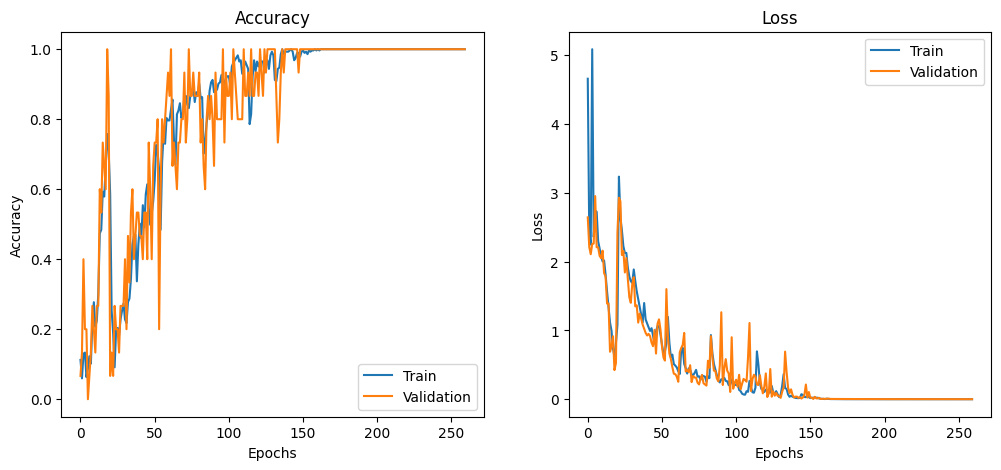

In [56]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(lstm_history.history['categorical_accuracy'])
plt.plot(lstm_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [57]:
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(64, return_sequences=True, activation='relu', input_shape=(30,1662)),
    GRU(128, return_sequences=True, activation='relu'),
    GRU(64, return_sequences=False, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(actions.shape[0], activation='softmax')
])

gru_model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

gru_history = gru_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])
gru_model.summary()

Epoch 1/260
9/9 [==============================] - 6s 166ms/step - loss: 2.2955 - categorical_accuracy: 0.1018 - val_loss: 2.2615 - val_categorical_accuracy: 0.2000
Epoch 2/260
9/9 [==============================] - 1s 101ms/step - loss: 2.2098 - categorical_accuracy: 0.2070 - val_loss: 2.1338 - val_categorical_accuracy: 0.2000
Epoch 3/260
9/9 [==============================] - 1s 101ms/step - loss: 1.9410 - categorical_accuracy: 0.2175 - val_loss: 1.7225 - val_categorical_accuracy: 0.3333
Epoch 4/260
9/9 [==============================] - 1s 115ms/step - loss: 1.5183 - categorical_accuracy: 0.4175 - val_loss: 1.3505 - val_categorical_accuracy: 0.5333
Epoch 5/260
9/9 [==============================] - 1s 108ms/step - loss: 1.1897 - categorical_accuracy: 0.5509 - val_loss: 0.8789 - val_categorical_accuracy: 0.6667
Epoch 6/260
9/9 [==============================] - 1s 98ms/step - loss: 0.9195 - categorical_accuracy: 0.6140 - val_loss: 1.0815 - val_categorical_accuracy: 0.5333
Epoch 7/260

In [58]:
gru_res = gru_model.predict(X_test)
print(actions[np.argmax(gru_res[0])], actions[np.argmax(y_test[0])])

1/1 [==============================] - 0s 394ms/step
Where are you from Where are you from


In [59]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = gru_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 37ms/step


1.0

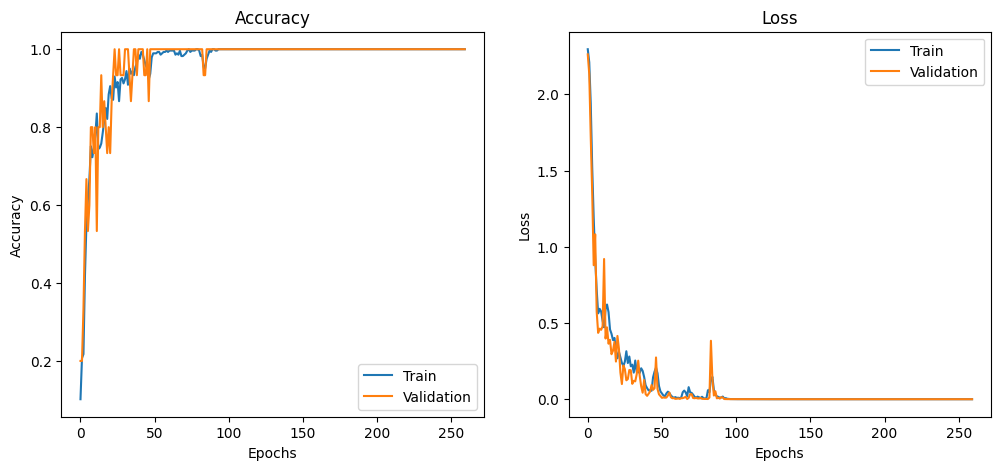

In [60]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(gru_history.history['categorical_accuracy'])
plt.plot(gru_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(gru_history.history['loss'])
plt.plot(gru_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [61]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(30,1662)),
    MaxPooling1D(2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(actions.shape[0], activation='softmax')
])

cnn_model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

cnn_history = cnn_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])
cnn_model.summary()

Epoch 1/260
9/9 [==============================] - 1s 58ms/step - loss: 2.3648 - categorical_accuracy: 0.1123 - val_loss: 2.3444 - val_categorical_accuracy: 0.0000e+00
Epoch 2/260
9/9 [==============================] - 0s 43ms/step - loss: 2.1932 - categorical_accuracy: 0.1544 - val_loss: 2.0284 - val_categorical_accuracy: 0.3333
Epoch 3/260
9/9 [==============================] - 0s 37ms/step - loss: 1.9723 - categorical_accuracy: 0.2000 - val_loss: 1.7970 - val_categorical_accuracy: 0.3333
Epoch 4/260
9/9 [==============================] - 0s 35ms/step - loss: 1.7894 - categorical_accuracy: 0.2526 - val_loss: 1.6145 - val_categorical_accuracy: 0.5333
Epoch 5/260
9/9 [==============================] - 0s 36ms/step - loss: 1.6300 - categorical_accuracy: 0.2947 - val_loss: 1.5176 - val_categorical_accuracy: 0.4667
Epoch 6/260
9/9 [==============================] - 0s 39ms/step - loss: 1.4756 - categorical_accuracy: 0.4140 - val_loss: 1.4055 - val_categorical_accuracy: 0.5333
Epoch 7/260


In [62]:
cnn_res = cnn_model.predict(X_test)
print(actions[np.argmax(cnn_res[0])], actions[np.argmax(y_test[0])])

1/1 [==============================] - 0s 81ms/step
Where are you from Where are you from


In [63]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = cnn_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 27ms/step


1.0

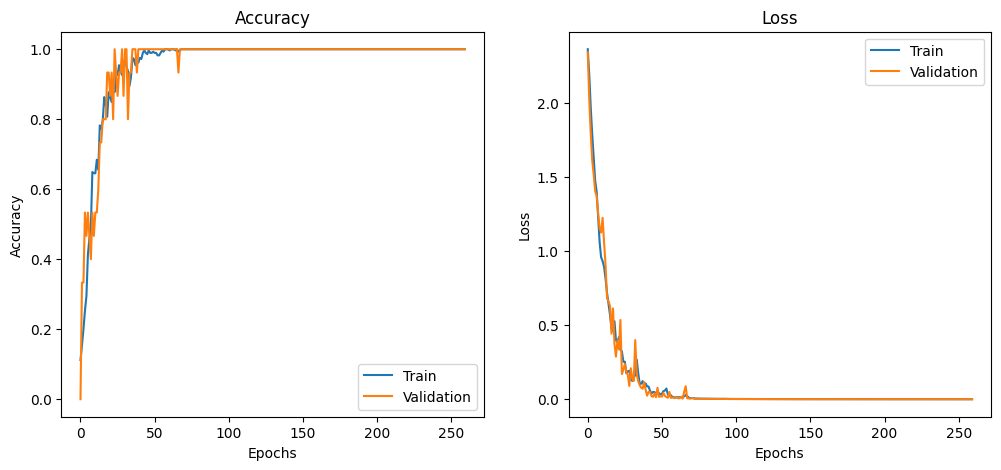

In [64]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history.history['categorical_accuracy'])
plt.plot(cnn_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [65]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization,
    MultiHeadAttention, Dropout,
    GlobalAveragePooling1D, Embedding, Add
)
from tensorflow.keras.models import Model


# Positional Encoding
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_emb = Embedding(seq_len, d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        return x + self.pos_emb(positions)


inputs = Input(shape=(30, 1662))
x = Dense(128)(inputs)          # reduce dimension first
x = PositionalEmbedding(30, 128)(x)

attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = Add()([x, attn])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(actions.shape[0], activation='softmax')(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

transformer_history = transformer_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])
transformer_model.summary()

Epoch 1/260
9/9 [==============================] - 2s 52ms/step - loss: 2.3591 - categorical_accuracy: 0.0947 - val_loss: 2.3356 - val_categorical_accuracy: 0.0667
Epoch 2/260
9/9 [==============================] - 0s 30ms/step - loss: 2.1751 - categorical_accuracy: 0.2561 - val_loss: 2.1401 - val_categorical_accuracy: 0.3333
Epoch 3/260
9/9 [==============================] - 0s 31ms/step - loss: 2.0474 - categorical_accuracy: 0.3789 - val_loss: 2.0112 - val_categorical_accuracy: 0.3333
Epoch 4/260
9/9 [==============================] - 0s 33ms/step - loss: 1.9156 - categorical_accuracy: 0.4632 - val_loss: 1.9035 - val_categorical_accuracy: 0.4000
Epoch 5/260
9/9 [==============================] - 0s 31ms/step - loss: 1.7826 - categorical_accuracy: 0.4877 - val_loss: 1.7392 - val_categorical_accuracy: 0.4667
Epoch 6/260
9/9 [==============================] - 0s 34ms/step - loss: 1.5983 - categorical_accuracy: 0.5684 - val_loss: 1.5216 - val_categorical_accuracy: 0.6000
Epoch 7/260
9/9 

In [66]:
transformer_res = transformer_model.predict(X_test)
print(actions[np.argmax(transformer_res[0])], actions[np.argmax(y_test[0])])

1/1 [==============================] - 0s 118ms/step
Where are you from Where are you from


In [67]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = transformer_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 28ms/step


1.0

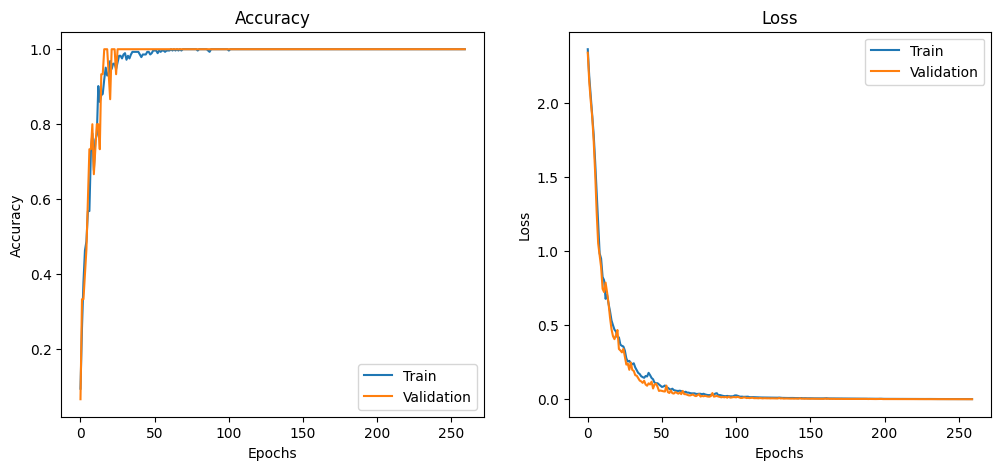

In [68]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(transformer_history.history['categorical_accuracy'])
plt.plot(transformer_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(transformer_history.history['loss'])
plt.plot(transformer_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

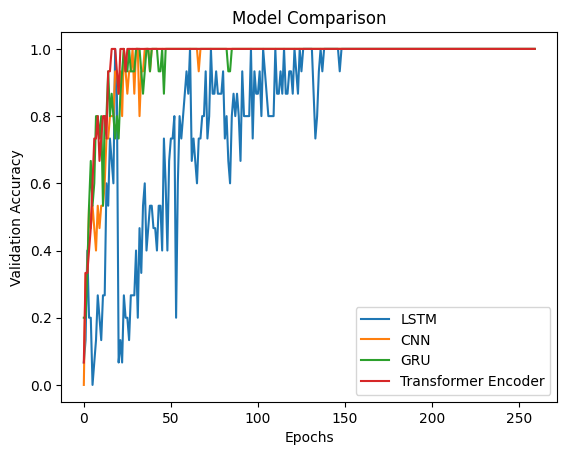

In [69]:
histories = {
    "LSTM": lstm_history,
    "CNN": cnn_history,
    "GRU": gru_history,
    "Transformer Encoder": transformer_history
    
}

plt.figure()
for name, hist in histories.items():
    plt.plot(hist.history['val_categorical_accuracy'], label=name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison')
plt.legend()
plt.show()

In [ ]:
lstm_model.save('lstm_asl.h5')
cnn_model.save('cnn_asl.h5')
gru_model.save('gru_asl.h5')
transformer_model.save('transformer_asl.h5')

In [71]:
lstm_model.load_weights('lstm_asl.h5')
cnn_model.load_weights('cnn_asl.h5')
gru_model.load_weights('gru_asl.h5')
transformer_model.load_weights('transformer_asl.h5')

In [72]:
from scipy import stats

In [73]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame
plt.figure(figsize=(18,18))

<Figure size 1800x1800 with 0 Axes>

<Figure size 1800x1800 with 0 Axes>

In [74]:
plt.imshow(prob_viz(res, actions, image, colors))

IndexError: list index out of range

In [ ]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = lstm_model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

IndexError: list index out of range

: 